In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
import xgboost as xgb
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("nhamcs_data_2018_22.csv")


In [3]:
df.columns

Index(['visit_month', 'day_of_week', 'arrival_time', 'ems_arrival',
       'vitals_during_visit', 'age', 'residence', 'sex', 'insurance',
       'no_payment', 'region', 'temp', 'heart_rate', 'resp_rate', 'sys_bp',
       'dias_bp', 'spo2', 'pain_score', 'seen_last_72h', 'episode',
       'is_injury_poison', 'hist_alzheimers', 'hist_asthma', 'hist_cancer',
       'hist_stroke', 'hist_ckd', 'hist_copd', 'hist_chf', 'hist_cad',
       'hist_depression', 'hist_diabetes_t1', 'hist_diabetes_t2',
       'hist_diabetes_unspec', 'hist_esrd', 'hist_pe', 'hist_hiv',
       'hist_high_cholesterol', 'hist_hypertension', 'hist_obesity',
       'hist_sleep_apnea', 'hist_osteoporosis', 'hist_substance_abuse',
       'intervention_iv_fluids', 'target_triage_acuity', 'wait_time_minutes',
       'race', 'year', 'chief_complaint_text', 'injury_cause_text'],
      dtype='str')

In [4]:
import numpy as np

print("Applying Cyclical Encoding to Time Features...")

# 1. Clean and convert arrival_time (HHMM integer) to a continuous hour scale (0 to 23.99)
# Example: 1430 -> 14 hours + (30/60) minutes = 14.5
if 'arrival_time' in df.columns:
    # Set missing or invalid times (often negative in NHAMCS) to NaN    
    df['arrival_time'] = np.where(df['arrival_time'] < 0, np.nan, df['arrival_time'])
    
    # Extract hours and minutes
    hours = np.floor_divide(df['arrival_time'], 100)
    minutes = np.mod(df['arrival_time'], 100)
    
    # Create the continuous hour feature
    df['arrival_hour_float'] = hours + (minutes / 60.0)

# 2. Define the exact maximum values for a full cycle
cycle_maxes = {
    'visit_month': 12.0,
    'day_of_week': 7.0,
    'arrival_hour_float': 24.0
}

# 3. Apply the Sine and Cosine Transformations
for col, max_val in cycle_maxes.items():
    if col in df.columns:
        # Calculate the angle on the circle
        angle = 2 * np.pi * df[col] / max_val
        
        # Create the Sin and Cos features
        df[f'{col}_sin'] = np.sin(angle)
        df[f'{col}_cos'] = np.cos(angle)

# 4. Drop the original linear time columns to prevent multicollinearity
cols_to_drop = ['visit_month', 'day_of_week', 'arrival_time', 'arrival_hour_float']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print(f"Dataframe shape after cyclical encoding: {df.shape}")
print("\nSample of the new Time Features:")
display(df[[c for c in df.columns if '_sin' in c or '_cos' in c]].head())

Applying Cyclical Encoding to Time Features...
Dataframe shape after cyclical encoding: (58124, 52)

Sample of the new Time Features:


,visit_month_sin,visit_month_cos,day_of_week_sin,day_of_week_cos,arrival_hour_float_sin,arrival_hour_float_cos
0,-2.449294e-16,1.000000,0.781831,0.623490,-0.748956,0.662620
1,-2.449294e-16,1.000000,0.781831,0.623490,-0.957571,0.288196
2,-2.449294e-16,1.000000,-0.781831,0.623490,-0.625923,-0.779884
3,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.994522,-0.104528
4,-5.000000e-01,0.866025,0.974928,-0.222521,-0.983255,-0.182236


In [5]:
# --- NLP EMBEDDINGS (WITH CACHING) ---
from dataloader_helpers import generate_embeddings


print("NLP Embedding Logic...")

df_text = df[["chief_complaint_text", "injury_cause_text"]].fillna("")
df = df.drop(columns=["chief_complaint_text", "injury_cause_text"])
df_emb = generate_embeddings(df_text)

NLP Embedding Logic...
🚀 Loading cached embeddings from embeddings.parquet...


              precision    recall  f1-score   support

           0       0.62      0.07      0.13       178
           1       0.45      0.17      0.25      1706
           2       0.58      0.79      0.67      5895
           3       0.52      0.44      0.48      3358
           4       0.53      0.06      0.10       488

    accuracy                           0.56     11625
   macro avg       0.54      0.31      0.33     11625
weighted avg       0.54      0.56      0.52     11625



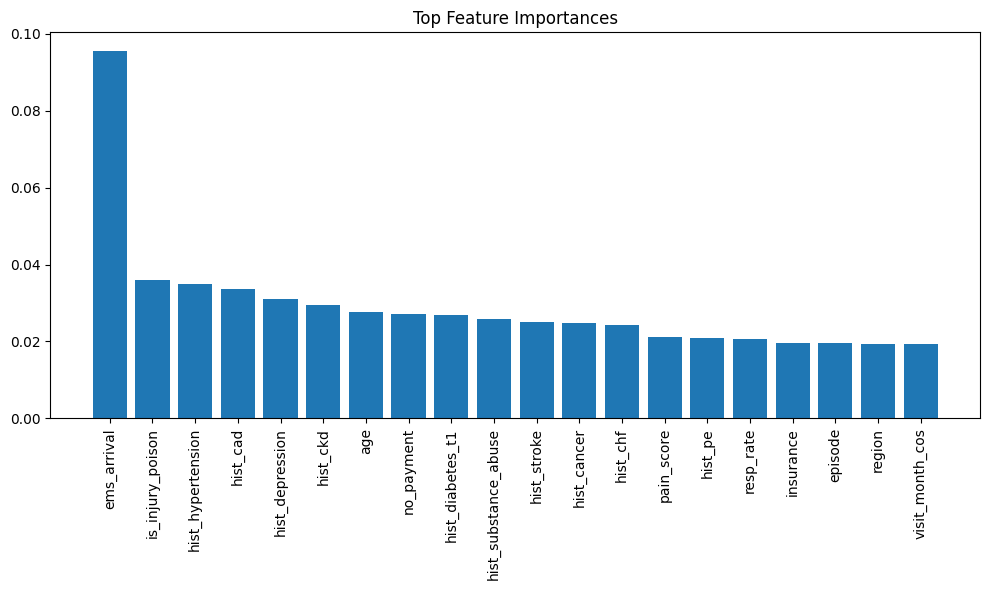

<Figure size 640x480 with 0 Axes>

In [6]:
from dataloader_helpers import data_split, plot_feature_importance
from models import train_xgboost
x_train, x_val, y_train, y_val = data_split(df, config="base_line", random_state=42)

baseline_model = train_xgboost(x_train, y_train, config="xgb_baseline")
y_pred = baseline_model.predict(x_val)
print(classification_report(y_val, y_pred))

plot_feature_importance(baseline_model, x_train.columns, top_n=20)

              precision    recall  f1-score   support

           0       0.29      0.14      0.19       178
           1       0.34      0.44      0.38      1706
           2       0.63      0.51      0.56      5895
           3       0.47      0.54      0.51      3358
           4       0.14      0.20      0.16       488

    accuracy                           0.49     11625
   macro avg       0.37      0.37      0.36     11625
weighted avg       0.51      0.49      0.50     11625



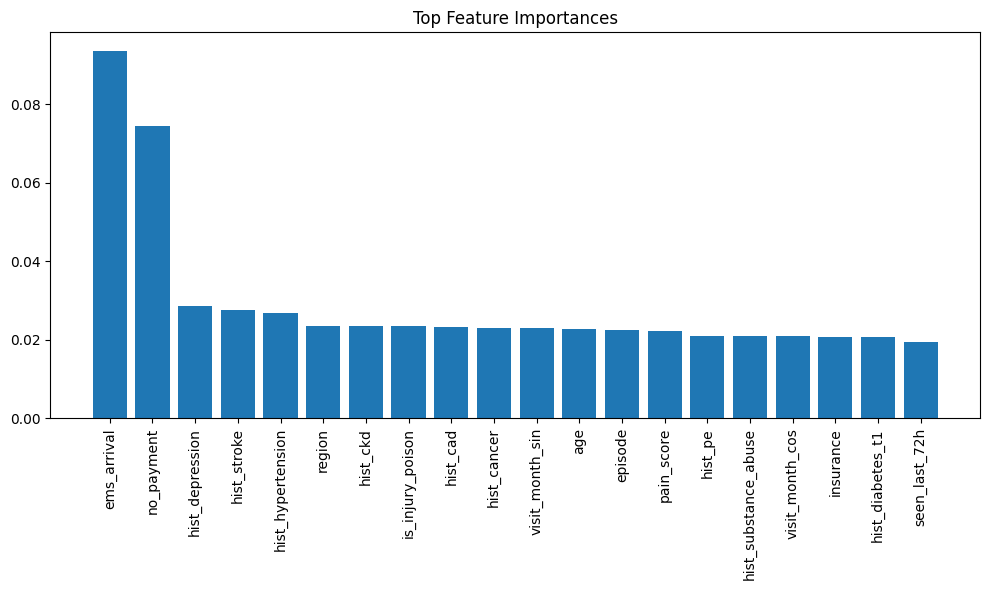

<Figure size 640x480 with 0 Axes>

In [7]:
weighted_model = train_xgboost(x_train, y_train, config="xgb_weighted")
y_pred = weighted_model.predict(x_val)
print(classification_report(y_val, y_pred))

plot_feature_importance(weighted_model, x_train.columns, top_n=20)

              precision    recall  f1-score   support

           0       0.43      0.13      0.20       178
           1       0.42      0.56      0.48      1706
           2       0.70      0.57      0.63      5895
           3       0.54      0.65      0.59      3358
           4       0.26      0.26      0.26       488

    accuracy                           0.57     11625
   macro avg       0.47      0.43      0.43     11625
weighted avg       0.59      0.57      0.58     11625



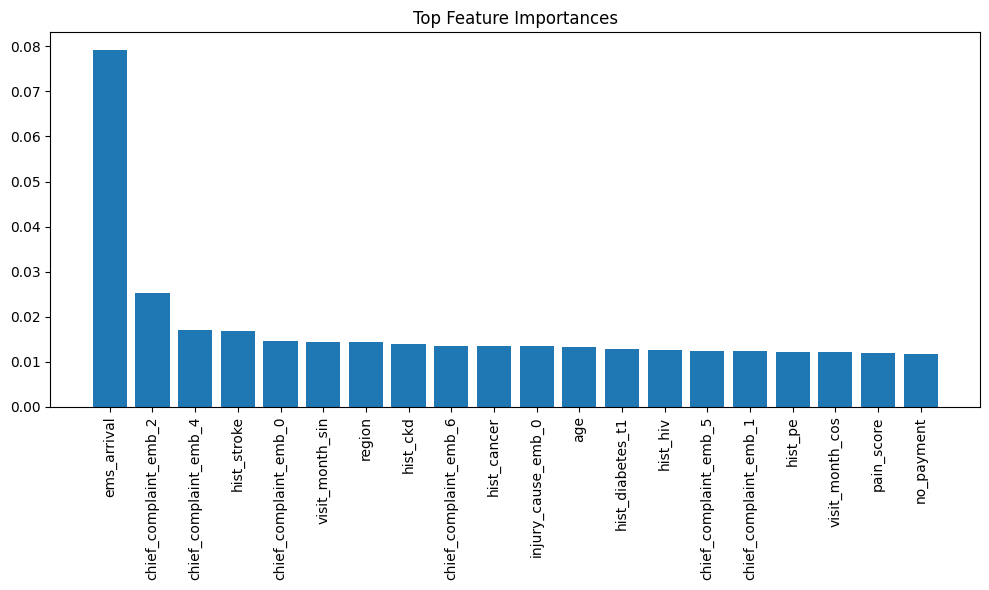

<Figure size 640x480 with 0 Axes>

In [8]:
from models import train_xgboost

df = pd.concat([df, df_emb], axis=1)
x_train, x_val, y_train, y_val = data_split(df, config="base_line", random_state=42)
nlp_model = train_xgboost(x_train, y_train, config="xgb_weighted")
y_pred = nlp_model.predict(x_val)
print(classification_report(y_val, y_pred))
plot_feature_importance(nlp_model, x_train.columns, top_n=20)

In [9]:
from models import train_ebm

emb_model = train_ebm(x_train, y_train)
y_pred = emb_model.predict(x_val)
print(classification_report(y_val, y_pred))
plot_feature_importance(emb_model, x_train.columns, top_n=20)

/home/gaurav/python/kaggle/triage/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(
/home/gaurav/python/kaggle/triage/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(


              precision    recall  f1-score   support

           0       0.59      0.11      0.18       178
           1       0.53      0.25      0.34      1706
           2       0.63      0.78      0.70      5895
           3       0.58      0.59      0.58      3358
           4       0.64      0.07      0.12       488

    accuracy                           0.61     11625
   macro avg       0.59      0.36      0.38     11625
weighted avg       0.60      0.61      0.58     11625

Model does not have feature importance attribute.


/home/gaurav/python/kaggle/triage/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term ems_arrival & chief_complaint_emb_2 from explanation since we can't graph multinomial interactions.
  warn(
/home/gaurav/python/kaggle/triage/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term age & chief_complaint_emb_0 from explanation since we can't graph multinomial interactions.
  warn(
/home/gaurav/python/kaggle/triage/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term age & chief_complaint_emb_4 from explanation since we can't graph multinomial interactions.
  warn(
/home/gaurav/python/kaggle/triage/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning: Dropping term insurance & visit_month_cos from explanation since we can't graph multinomial interactions.
  warn(
/home/gaurav/python/kaggle/triage/.venv/lib/python3.12/s

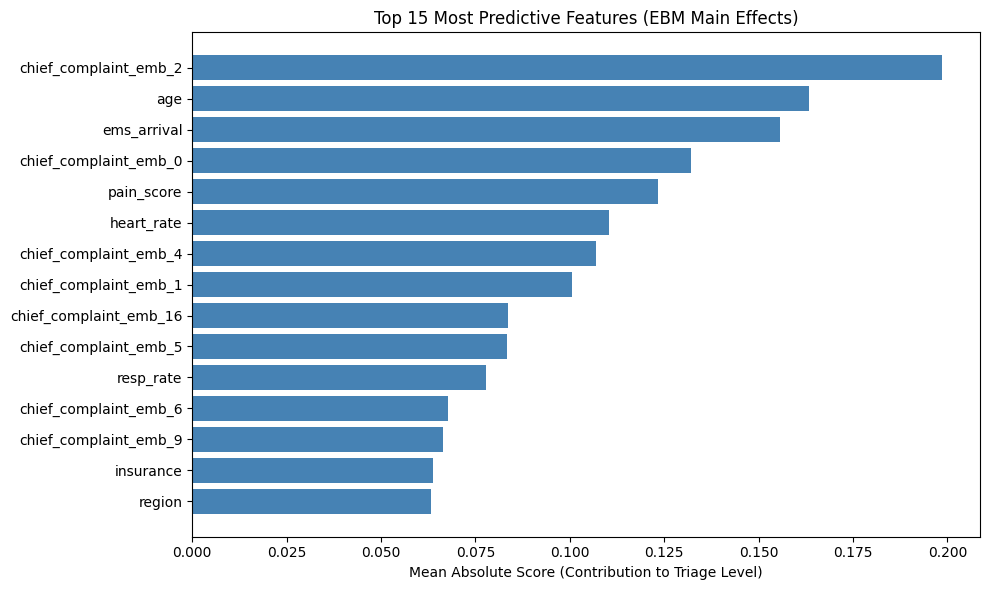

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the global explanation object
ebm_global = emb_model.explain_global(name='Triage Logic')

# 2. Extract raw data
data = ebm_global.data()
features = data['names']
importances = data['scores']

# 3. Filter out interactions (the ones with '&' causing the error)
main_indices = [i for i, name in enumerate(features) if ' & ' not in name]
main_features = [features[i] for i in main_indices]
main_scores = [importances[i] for i in main_indices]

# 4. Sort and plot the Top 15
sorted_idx = np.argsort(main_scores)[-15:]
top_features = [main_features[i] for i in sorted_idx]
top_scores = [main_scores[i] for i in sorted_idx]

plt.figure(figsize=(10, 6))
plt.barh(top_features, top_scores, color='steelblue')
plt.title("Top 15 Most Predictive Features (EBM Main Effects)")
plt.xlabel("Mean Absolute Score (Contribution to Triage Level)")
plt.tight_layout()
plt.show()

In [12]:
# 1. Find the exact column index for the feature you want to plot
# Change 'shock_index' to whatever feature you want to inspect
feature_name = 'race' 
feature_idx = x_train.columns.get_loc(feature_name)

# 2. Extract the Plotly figure directly from the EBM object
fig = ebm_global.visualize(feature_idx)

# 3. Force Plotly to render inline in the notebook
fig.update_layout(
    title=f'EBM Shape Function: {feature_name}',
    height=500,
    width=800
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed